# Meridional means, and why they are harder

The previous example got a zonal mean for nothing, because HEALPix is built
out of rings of constant latitude. It is tempting to assume the transpose
works too, and that averaging along a meridian is equally free.

It is not, and the reason is worth a page: HEALPix has rows but no columns.
Each ring is rotated relative to the one below it, and rings hold different
numbers of cells, so no set of cells lines up along a meridian. A meridional
mean has to be binned, which makes it the first operation in the examples
that involves a choice you have to defend.

*The figure is saved with this notebook. Run the cells in order, from the top, to compute it again. The same example on the web: [Meridional means, and why they are harder](https://waterpark.dkrz.de/docs/examples/05_meridional_mean/).*

## Look at the grid up close

This example uses level 4 rather than the level 7 of the last one, because
the point is the arrangement of individual cells and at level 7 they are
too small to see. Everything below scales to any level; only the numbers
in the last section change.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

URL = "s3://reanalysis/healpix/era5/P1M/level_4.zarr"
S3 = {"anon": True, "endpoint_url": "https://s3.waterpark.dkrz.de"}

ds = xr.open_zarr(URL, storage_options=S3, chunks=None)
level = ds.attrs["healpix_level"]

longitude = ds["longitude"].values
longitude = np.where(longitude > 180.0, longitude - 360.0, longitude)
latitude = ds["latitude"].values
_, rings = np.unique(np.round(latitude, 8), return_inverse=True)

window = (np.abs(longitude) < 40) & (np.abs(latitude - 30) < 25)
print(f"{np.count_nonzero(window)} cells in the close-up window")

Cells on one ring are evenly spaced in longitude, but the spacing and the
offset both depend on the ring. Two adjacent rings are staggered by half a
cell, and a ring in the polar cap holds fewer cells than one in the belt,
so the longitudes on different rings simply do not coincide.

In [ ]:
for ring in np.unique(rings[window])[:4]:
    lons = np.sort(longitude[rings == ring])
    print(
        f"ring {ring:3d} at {latitude[rings == ring][0]:+6.2f} deg: "
        f"{lons.size:3d} cells, first at {lons[0]:+7.2f}, "
        f"spacing {np.diff(lons)[0]:.2f} deg"
    )

## So bin

Assign each cell to a longitude bin and average within it. Because the
cells are equal area, the plain mean over the cells that land in a bin is
already the area weighted mean over that wedge, which removes the one part
of binning that usually goes wrong.

What remains is the bin width, and it is a real trade-off: too wide and
you smear features, too narrow and the bin counts become erratic, because
a narrow wedge collects a different number of cells from each ring it
crosses.

In [ ]:
band = (latitude > 20) & (latitude < 60)
field = ds["tas"].sel(time=slice("2021-01", "2021-12")).mean("time").load()
values = field.values[band]


def meridional_mean(nbins):
    edges = np.linspace(-180, 180, nbins + 1)
    index = np.digitize(longitude[band], edges) - 1
    means = np.array(
        [
            values[index == b].mean() if np.any(index == b) else np.nan
            for b in range(nbins)
        ]
    )
    counts = np.bincount(index[index >= 0], minlength=nbins)
    return 0.5 * (edges[:-1] + edges[1:]), means, counts


coarse = meridional_mean(24)
fine = meridional_mean(96)

print(f"24 bins: {coarse[2].min()}-{coarse[2].max()} cells per bin")
print(f"96 bins: {fine[2].min()}-{fine[2].max()} cells per bin")

## The plot

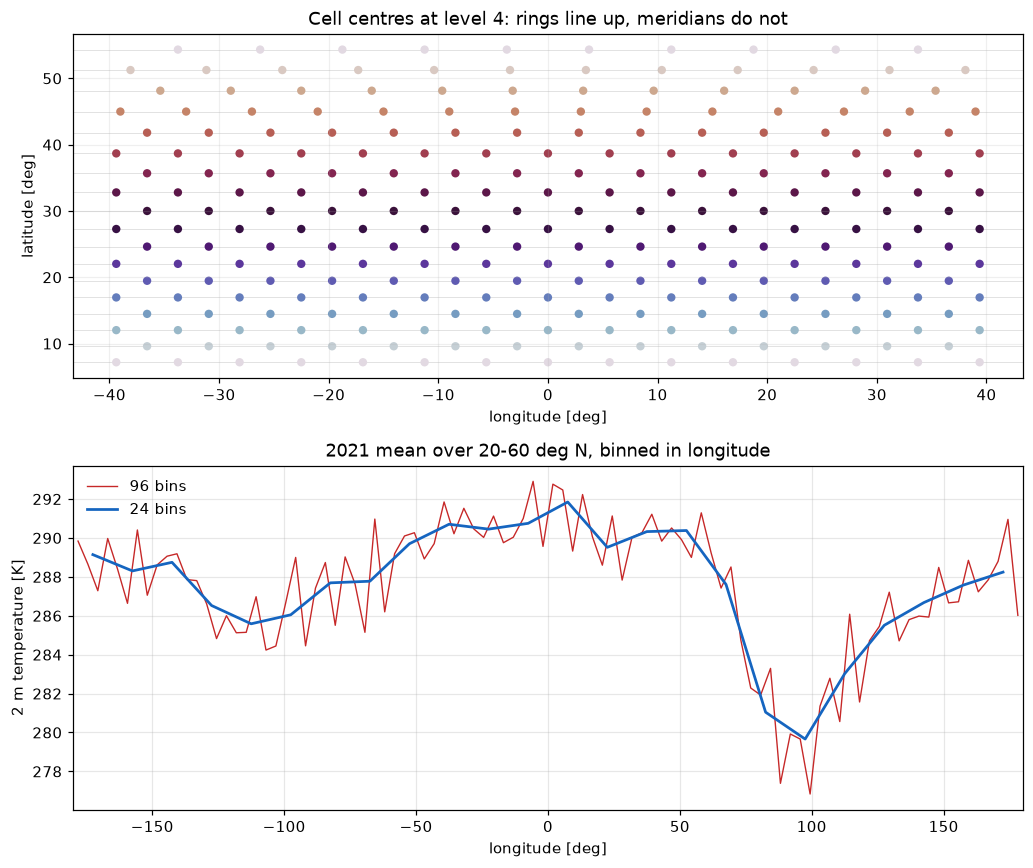

In [ ]:
fig, (ax_grid, ax_mean) = plt.subplots(2, 1, figsize=(9.5, 8))

ax_grid.scatter(
    longitude[window],
    latitude[window],
    c=rings[window],
    cmap="twilight",
    s=30,
    edgecolor="none",
)
for ring in np.unique(rings[window]):
    ax_grid.axhline(latitude[rings == ring][0], color="0.88", lw=0.6, zorder=0)
ax_grid.set_title(f"Cell centres at level {level}: rings line up, meridians do not")
ax_grid.set_xlabel("longitude [deg]")
ax_grid.set_ylabel("latitude [deg]")
ax_grid.grid(alpha=0.2)

ax_mean.plot(fine[0], fine[1], color="#c62828", lw=0.9, label="96 bins")
ax_mean.plot(coarse[0], coarse[1], color="#1565c0", lw=1.8, label="24 bins")
ax_mean.set_xlim(-180, 180)
ax_mean.set_xlabel("longitude [deg]")
ax_mean.set_ylabel("2 m temperature [K]")
ax_mean.set_title("2021 mean over 20-60 deg N, binned in longitude")
ax_mean.grid(alpha=0.3)
ax_mean.legend(frameon=False)

fig.tight_layout()
fig.savefig("05_meridional_mean.png", dpi=110, bbox_inches="tight", facecolor="white")
plt.show()

## Choosing the width

A defensible default is one bin per cell width at the **coarsest** ring in
your band, which at level `k` is `360 / (4 * 2**k)` degrees in the
equatorial belt and wider towards the poles. At level 4 that is 5.6
degrees, so 64 bins around the globe; the 96-bin curve above is finer than
that, and its wiggle is the grid talking rather than the atmosphere.

The same rule at level 7 gives 512 bins, which is the sense in which this
problem goes away with resolution. It never quite disappears, though, and
the honest summary is this: HEALPix is an excellent grid for anything that
respects the sphere's symmetry, and a slightly awkward one for anything
phrased in terms of a rectangular lattice. Knowing which of the two you
are doing is most of the skill.